开始读取数据...
train: (260864, 3)
test: (261477, 3)
user_log: (3000000, 7)
开始构建用户-商家特征...
开始构建转化率特征...
开始构建用户全局特征...
开始构建商家特征...
开始合并特征...
训练集: (208691, 21)
验证集: (52173, 21)
开始训练模型...

🚀 升级版 AUC = 0.6532


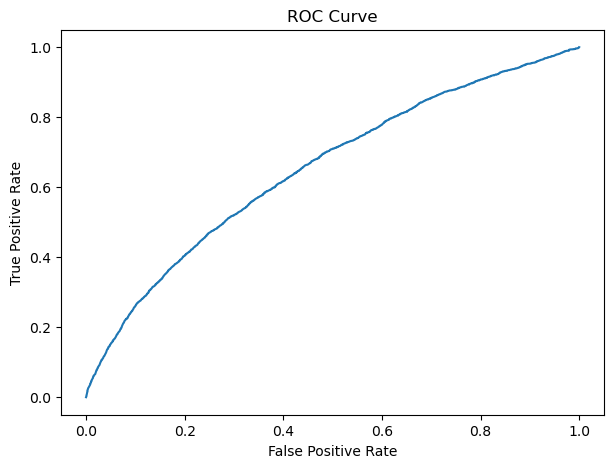


Top 特征重要性：
              feature  importance
16          m_buy_cnt    0.172572
17        m_total_act    0.169894
15         m_user_cnt    0.161004
18  merchant_buy_rate    0.156407
20             gender    0.094816
14     u_action_types    0.085475
19          age_range    0.080890
13      u_active_days    0.078943
11        u_total_buy    0.000000
12        u_total_act    0.000000
0               click    0.000000
1                cart    0.000000
9            cart2buy    0.000000
8           click2buy    0.000000
7            buy_rate    0.000000


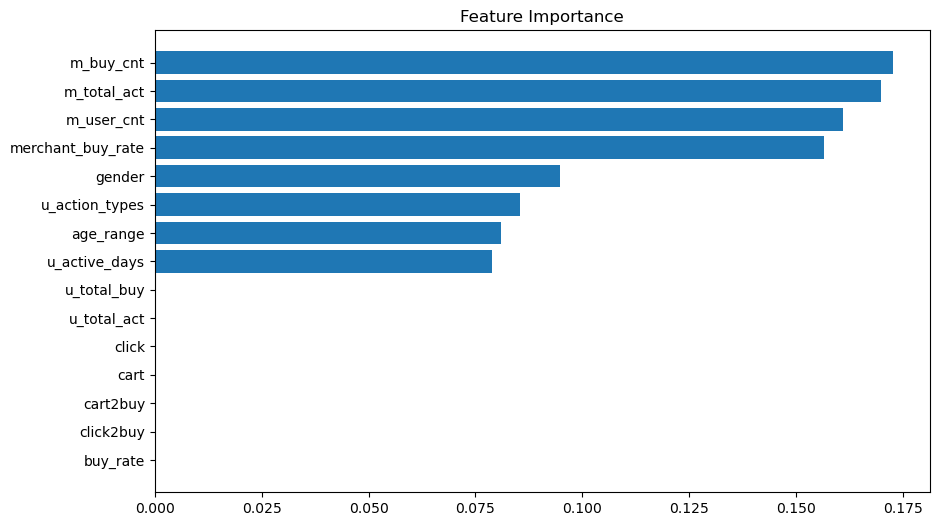


🎉 项目升级完成！
submission_best.csv 已生成！


In [5]:
# ====================== 天猫复购预测 - 升级版 ======================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

from xgboost import XGBClassifier

# =========================================================
# 1. 数据读取
# =========================================================

path = r"C:\Users\Administrator\Desktop\工作\项目二天猫用户重复购买预测\data_format1"

print("开始读取数据...")

train = pd.read_csv(
    path + r"\train_format1.csv"
)

test = pd.read_csv(
    path + r"\test_format1.csv"
)

user_info = pd.read_csv(
    path + r"\user_info_format1.csv"
)

# 300万行为日志
user_log = pd.read_csv(
    path + r"\user_log_format1.csv",
    nrows=3000000
)

print("train:", train.shape)
print("test:", test.shape)
print("user_log:", user_log.shape)

# =========================================================
# 2. 缺失值处理
# =========================================================

user_info["age_range"] = user_info["age_range"].fillna(0)
user_info["gender"] = user_info["gender"].fillna(2)

# =========================================================
# 3. 用户-商家行为特征
# =========================================================

print("开始构建用户-商家特征...")

user_merchant = user_log.groupby(
    ['user_id', 'seller_id']
).agg(

    click=('action_type', lambda x:(x==0).sum()),
    cart=('action_type', lambda x:(x==1).sum()),
    buy=('action_type', lambda x:(x==2).sum()),
    fav=('action_type', lambda x:(x==3).sum()),

    total=('action_type','count'),

    # 活跃天数（新增）
    active_days=('time_stamp','nunique'),

    # 行为种类数（新增）
    action_nunique=('action_type','nunique')

).reset_index()

user_merchant.rename(
    columns={'seller_id':'merchant_id'},
    inplace=True
)

# =========================================================
# 4. 转化率特征（核心）
# =========================================================

print("开始构建转化率特征...")

user_merchant['buy_rate'] = (
    user_merchant['buy'] /
    (user_merchant['total'] + 1e-9)
)

user_merchant['click2buy'] = (
    user_merchant['buy'] /
    (user_merchant['click'] + 1e-9)
)

user_merchant['cart2buy'] = (
    user_merchant['buy'] /
    (user_merchant['cart'] + 1e-9)
)

user_merchant['fav2buy'] = (
    user_merchant['buy'] /
    (user_merchant['fav'] + 1e-9)
)

# =========================================================
# 5. 用户全局特征
# =========================================================

print("开始构建用户全局特征...")

user_feat = user_log.groupby('user_id').agg(

    u_total_buy=('action_type', lambda x:(x==2).sum()),

    u_total_act=('action_type','count'),

    # 用户活跃天数
    u_active_days=('time_stamp','nunique'),

    # 用户行为种类数
    u_action_types=('action_type','nunique')

).reset_index()

# =========================================================
# 6. 商家特征
# =========================================================

print("开始构建商家特征...")

merchant_feat = user_log.groupby('seller_id').agg(

    m_user_cnt=('user_id','nunique'),

    m_buy_cnt=('action_type', lambda x:(x==2).sum()),

    m_total_act=('action_type','count')

).reset_index()

merchant_feat.rename(
    columns={'seller_id':'merchant_id'},
    inplace=True
)

# 商家转化率（新增）
merchant_feat['merchant_buy_rate'] = (
    merchant_feat['m_buy_cnt'] /
    (merchant_feat['m_total_act'] + 1e-9)
)

# =========================================================
# 7. 合并特征
# =========================================================

print("开始合并特征...")

train = train.merge(
    user_merchant,
    on=['user_id','merchant_id'],
    how='left'
)

train = train.merge(
    user_feat,
    on='user_id',
    how='left'
)

train = train.merge(
    merchant_feat,
    on='merchant_id',
    how='left'
)

train = train.merge(
    user_info,
    on='user_id',
    how='left'
)

test = test.merge(
    user_merchant,
    on=['user_id','merchant_id'],
    how='left'
)

test = test.merge(
    user_feat,
    on='user_id',
    how='left'
)

test = test.merge(
    merchant_feat,
    on='merchant_id',
    how='left'
)

test = test.merge(
    user_info,
    on='user_id',
    how='left'
)

# =========================================================
# 8. 特征列表
# =========================================================

feats = [

    'click',
    'cart',
    'buy',
    'fav',
    'total',

    'active_days',
    'action_nunique',

    'buy_rate',
    'click2buy',
    'cart2buy',
    'fav2buy',

    'u_total_buy',
    'u_total_act',
    'u_active_days',
    'u_action_types',

    'm_user_cnt',
    'm_buy_cnt',
    'm_total_act',
    'merchant_buy_rate',

    'age_range',
    'gender'
]

train[feats] = train[feats].fillna(0)
test[feats] = test[feats].fillna(0)

# =========================================================
# 9. 数据集划分
# =========================================================

X = train[feats]
y = train['label']

X = X[y != -1]
y = y[y != -1]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("训练集:", X_train.shape)
print("验证集:", X_val.shape)

# =========================================================
# 10. XGBoost 模型
# =========================================================

print("开始训练模型...")

model = XGBClassifier(

    n_estimators=500,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    min_child_weight=5,

    gamma=0.1,

    random_state=42,

    eval_metric='auc'
)

model.fit(X_train, y_train)

# =========================================================
# 11. 模型评估
# =========================================================

val_pred = model.predict_proba(X_val)[:,1]

auc = roc_auc_score(y_val, val_pred)

print("\n=====================================")
print(f"🚀 升级版 AUC = {auc:.4f}")
print("=====================================")

# =========================================================
# 12. ROC曲线
# =========================================================

fpr, tpr, _ = roc_curve(y_val, val_pred)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

# =========================================================
# 13. 特征重要性
# =========================================================

importance_df = pd.DataFrame({

    'feature': feats,

    'importance': model.feature_importances_

})

importance_df = importance_df.sort_values(
    by='importance',
    ascending=False
)

print("\nTop 特征重要性：")
print(importance_df.head(15))

# 特征重要性图
plt.figure(figsize=(10,6))

plt.barh(
    importance_df['feature'].head(15),
    importance_df['importance'].head(15)
)

plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.show()

# =========================================================
# 14. 测试集预测
# =========================================================

test['prob'] = model.predict_proba(
    test[feats]
)[:,1]

test[['user_id','merchant_id','prob']].to_csv(

    "submission_best.csv",

    index=False
)

print("\n🎉 项目升级完成！")
print("submission_best.csv 已生成！")

In [2]:
import pandas as pd

path = r"C:\Users\Administrator\Desktop\工作\项目二天猫用户重复购买预测\data_format1"

tmp = pd.read_csv(
    path + r"\user_log_format1.csv",
    nrows=5
)

print(tmp.columns)

Index(['user_id', 'item_id', 'cat_id', 'seller_id', 'brand_id', 'time_stamp',
       'action_type'],
      dtype='object')


开始读取数据...
train: (260864, 3)
test: (261477, 3)
user_log: (3000000, 7)
开始处理缺失值...
开始构建用户-商家特征...
开始构建用户-商家特征...
开始构建转化率特征...
开始构建行为占比特征...
开始构建用户全局特征...
开始构建商家特征...
开始合并特征...
特征数量: 21
训练集: (208691, 21)
验证集: (52173, 21)
开始训练模型...

🚀 优化终版 AUC = 0.6412
绘制 ROC 曲线...


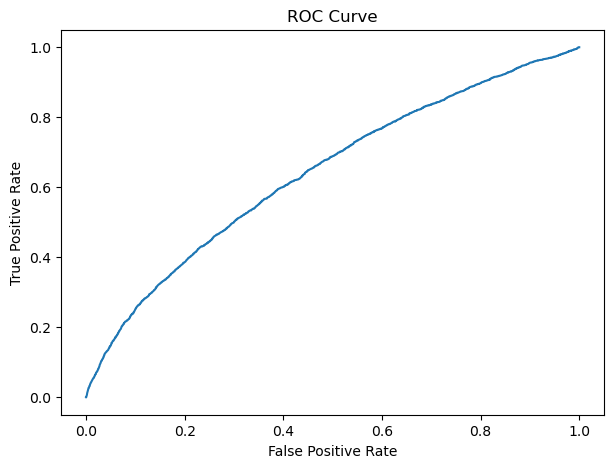


Top 特征重要性：
              feature  importance
18  merchant_buy_rate    0.094922
17          m_buy_cnt    0.093707
16         m_user_cnt    0.073865
9            cart2buy    0.066080
2                 buy    0.062595
5         active_days    0.058525
20             gender    0.051964
4               total    0.048313
10            fav2buy    0.046676
0               click    0.046458
11        click_ratio    0.043689
14      u_active_days    0.043598
7            buy_rate    0.041186
8           click2buy    0.040851
19          age_range    0.040443


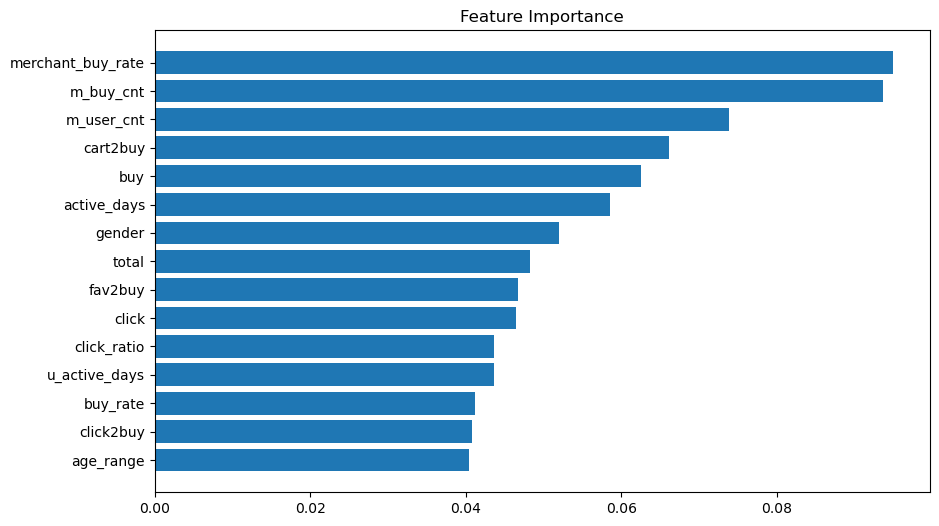

开始预测测试集...

🎉 项目优化完成！
submission_best.csv 已生成！
feature_importance.csv 已保存！


In [1]:
# ====================== 天猫复购预测 - 优化终版 ======================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

from xgboost import XGBClassifier

# =========================================================
# 1. 数据读取
# =========================================================

path = r"C:\Users\Administrator\Desktop\工作\项目二天猫用户重复购买预测\data_format1"

print("开始读取数据...")

train = pd.read_csv(
    path + r"\train_format1.csv"
)

test = pd.read_csv(
    path + r"\test_format1.csv"
)

user_info = pd.read_csv(
    path + r"\user_info_format1.csv"
)

# 读取300万行行为日志
user_log = pd.read_csv(
    path + r"\user_log_format1.csv",
    nrows=3000000
)

print("train:", train.shape)
print("test:", test.shape)
print("user_log:", user_log.shape)

# =========================================================
# 2. 缺失值处理
# =========================================================

print("开始处理缺失值...")

user_info["age_range"] = (
    user_info["age_range"]
    .fillna(0)
)

user_info["gender"] = (
    user_info["gender"]
    .fillna(2)
)

# =========================================================
# 3. 用户-商家行为特征
# =========================================================

print("开始构建用户-商家特征...")

print("开始构建用户-商家特征...")

# 行为统计（高速版）
action_df = pd.pivot_table(

    user_log,

    index=['user_id', 'seller_id'],

    columns='action_type',

    values='time_stamp',

    aggfunc='count',

    fill_value=0

).reset_index()

# 重命名
action_df.columns = [

    'user_id',
    'seller_id',

    'click',
    'cart',
    'buy',
    'fav'
]

# 总行为
action_df['total'] = (

    action_df['click'] +

    action_df['cart'] +

    action_df['buy'] +

    action_df['fav']
)

# 活跃天数
active_days = user_log.groupby(

    ['user_id', 'seller_id']

)['time_stamp'].nunique().reset_index(

    name='active_days'
)

# 行为种类数
action_nunique = user_log.groupby(

    ['user_id', 'seller_id']

)['action_type'].nunique().reset_index(

    name='action_nunique'
)

# 合并
user_merchant = action_df.merge(

    active_days,

    on=['user_id', 'seller_id'],

    how='left'
)

user_merchant = user_merchant.merge(

    action_nunique,

    on=['user_id', 'seller_id'],

    how='left'
)

# 改名
user_merchant.rename(

    columns={'seller_id':'merchant_id'},

    inplace=True
)

user_merchant.rename(
    columns={'seller_id':'merchant_id'},
    inplace=True
)

# =========================================================
# 4. 转化率特征（核心）
# =========================================================

print("开始构建转化率特征...")

# 购买率
user_merchant['buy_rate'] = (
    user_merchant['buy'] /
    (user_merchant['total'] + 1e-9)
)

# 点击转购买率
user_merchant['click2buy'] = (
    user_merchant['buy'] /
    (user_merchant['click'] + 1e-9)
)

# 加购转购买率
user_merchant['cart2buy'] = (
    user_merchant['buy'] /
    (user_merchant['cart'] + 1e-9)
)

# 收藏转购买率
user_merchant['fav2buy'] = (
    user_merchant['buy'] /
    (user_merchant['fav'] + 1e-9)
)

# =========================================================
# 5. 行为占比特征（新增优化）
# =========================================================

print("开始构建行为占比特征...")

# 点击占比
user_merchant['click_ratio'] = (
    user_merchant['click'] /
    (user_merchant['total'] + 1e-9)
)

# 加购占比
user_merchant['cart_ratio'] = (
    user_merchant['cart'] /
    (user_merchant['total'] + 1e-9)
)

# 收藏占比
user_merchant['fav_ratio'] = (
    user_merchant['fav'] /
    (user_merchant['total'] + 1e-9)
)

# =========================================================
# 6. 用户全局特征
# =========================================================

print("开始构建用户全局特征...")

user_feat = user_log.groupby('user_id').agg(

    # 用户活跃天数
    u_active_days=('time_stamp','nunique'),

    # 用户行为种类数
    u_action_types=('action_type','nunique')

).reset_index()

# =========================================================
# 7. 商家特征
# =========================================================

print("开始构建商家特征...")

merchant_feat = user_log.groupby('seller_id').agg(

    # 商家覆盖用户数
    m_user_cnt=('user_id','nunique'),

    # 商家购买次数
    m_buy_cnt=('action_type', lambda x:(x==2).sum())

).reset_index()

merchant_feat.rename(
    columns={'seller_id':'merchant_id'},
    inplace=True
)

# 商家转化率
merchant_feat['merchant_buy_rate'] = (

    merchant_feat['m_buy_cnt'] /

    (merchant_feat['m_user_cnt'] + 1e-9)
)

# =========================================================
# 8. 合并特征
# =========================================================

print("开始合并特征...")

train = train.merge(
    user_merchant,
    on=['user_id','merchant_id'],
    how='left'
)

train = train.merge(
    user_feat,
    on='user_id',
    how='left'
)

train = train.merge(
    merchant_feat,
    on='merchant_id',
    how='left'
)

train = train.merge(
    user_info,
    on='user_id',
    how='left'
)

test = test.merge(
    user_merchant,
    on=['user_id','merchant_id'],
    how='left'
)

test = test.merge(
    user_feat,
    on='user_id',
    how='left'
)

test = test.merge(
    merchant_feat,
    on='merchant_id',
    how='left'
)

test = test.merge(
    user_info,
    on='user_id',
    how='left'
)

# =========================================================
# 9. 特征列表
# =========================================================

feats = [

    # 用户-商家行为
    'click',
    'cart',
    'buy',
    'fav',
    'total',

    # 行为活跃度
    'active_days',
    'action_nunique',

    # 转化率
    'buy_rate',
    'click2buy',
    'cart2buy',
    'fav2buy',

    # 行为占比
    'click_ratio',
    'cart_ratio',
    'fav_ratio',

    # 用户特征
    'u_active_days',
    'u_action_types',

    # 商家特征
    'm_user_cnt',
    'm_buy_cnt',
    'merchant_buy_rate',

    # 用户画像
    'age_range',
    'gender'
]

train[feats] = train[feats].fillna(0)
test[feats] = test[feats].fillna(0)

print("特征数量:", len(feats))

# =========================================================
# 10. 数据集划分
# =========================================================

X = train[feats]
y = train['label']

X = X[y != -1]
y = y[y != -1]

X_train, X_val, y_train, y_val = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print("训练集:", X_train.shape)
print("验证集:", X_val.shape)

# =========================================================
# 11. XGBoost 模型
# =========================================================

print("开始训练模型...")

model = XGBClassifier(

    n_estimators=450,

    max_depth=5,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    min_child_weight=5,

    gamma=0.1,

    reg_alpha=0.1,

    reg_lambda=1,

    random_state=42,

    eval_metric='auc',

    n_jobs=-1
)

model.fit(X_train, y_train)

# =========================================================
# 12. 模型评估
# =========================================================

val_pred = model.predict_proba(X_val)[:,1]

auc = roc_auc_score(y_val, val_pred)

print("\n=====================================")
print(f"🚀 优化终版 AUC = {auc:.4f}")
print("=====================================")

# =========================================================
# 13. ROC 曲线
# =========================================================

print("绘制 ROC 曲线...")

fpr, tpr, _ = roc_curve(y_val, val_pred)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")
# --- 保存高清图---
plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight") 
# dpi=300 高清，bbox_inches="tight" 裁掉白边

plt.show()

# =========================================================
# 14. 特征重要性
# =========================================================

importance_df = pd.DataFrame({

    'feature': feats,

    'importance': model.feature_importances_

})

importance_df = importance_df.sort_values(

    by='importance',

    ascending=False
)

print("\nTop 特征重要性：")

print(importance_df.head(15))

# 可视化
plt.figure(figsize=(10,6))

plt.barh(

    importance_df['feature'].head(15),

    importance_df['importance'].head(15)

)

plt.title("Feature Importance")

plt.gca().invert_yaxis()
# --- 保存高清图---
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight") 

plt.show()

# =========================================================
# 15. 测试集预测
# =========================================================

print("开始预测测试集...")

test['prob'] = model.predict_proba(

    test[feats]

)[:,1]

# =========================================================
# 16. 保存结果
# =========================================================

submission = test[[
    'user_id',
    'merchant_id',
    'prob'
]]

submission.to_csv(

    "submission_best.csv",

    index=False
)

print("\n🎉 项目优化完成！")
print("submission_best.csv 已生成！")

# =========================================================
# 17. 保存特征重要性
# =========================================================

importance_df.to_csv(

    "feature_importance.csv",

    index=False
)

print("feature_importance.csv 已保存！")


In [3]:
import pandas as pd

# 路径
path = r"C:\Users\Administrator\Desktop\工作\项目二天猫用户重复购买预测\data_format1"

print("开始读取数据...")

# 读取300万行行为日志
user_log = pd.read_csv(
    path + r"\user_log_format1.csv",
    nrows=3000000
)

print(user_log.head())

print(user_log.shape)

开始读取数据...
   user_id  item_id  cat_id  seller_id  brand_id  time_stamp  action_type
0   328862   323294     833       2882    2661.0         829            0
1   328862   844400    1271       2882    2661.0         829            0
2   328862   575153    1271       2882    2661.0         829            0
3   328862   996875    1271       2882    2661.0         829            0
4   328862  1086186    1271       1253    1049.0         829            0
(3000000, 7)


开始读取数据...
train: (260864, 3)
user_info: (424170, 3)
user_log: (3000000, 7)
开始处理缺失值...

开始行为漏斗分析...

用户行为漏斗：
Click : 19865
Cart : 1215
Favorite : 11959
Purchase : 19877


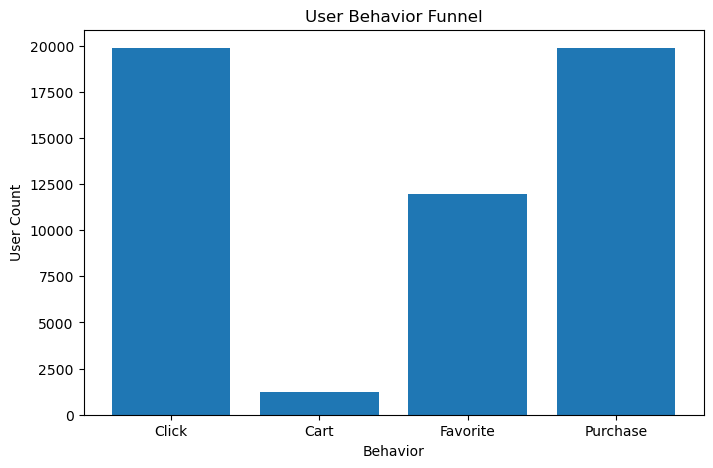


开始年龄分布分析...

年龄分布：
age_range
0.0     95131
1.0        24
2.0     52871
3.0    111654
4.0     79991
5.0     40777
6.0     35464
7.0      6992
8.0      1266
Name: count, dtype: int64


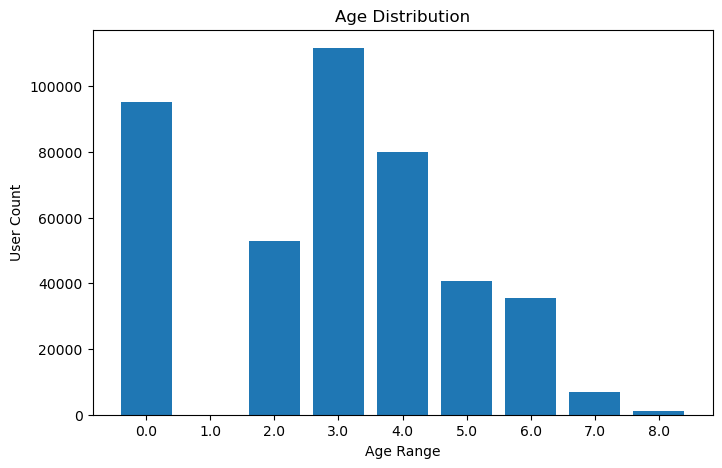


开始性别分布分析...

性别分布：
gender
0.0    285638
1.0    121670
2.0     16862
Name: count, dtype: int64


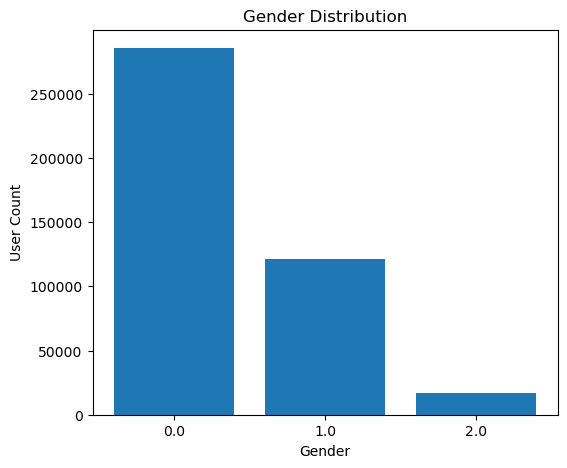


开始不同年龄复购率分析...

不同年龄复购率：
age_range
0.0    0.058217
1.0    0.000000
2.0    0.049346
3.0    0.058816
4.0    0.067220
5.0    0.069990
6.0    0.068338
7.0    0.060437
8.0    0.069444
Name: label, dtype: float64


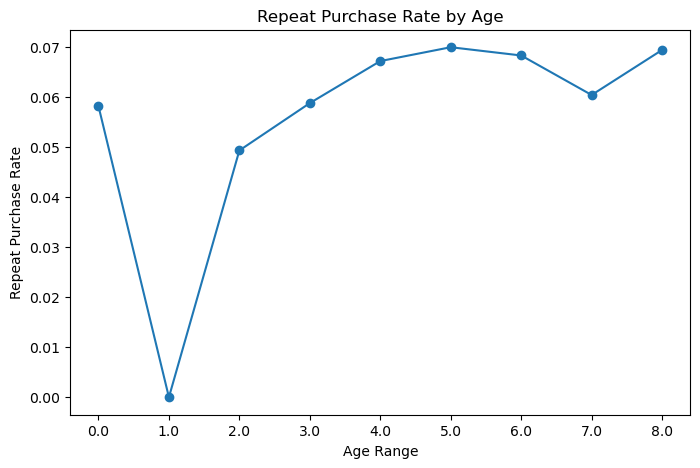


开始不同性别复购率分析...

不同性别复购率：
gender
0.0    0.064547
1.0    0.053813
2.0    0.055732
Name: label, dtype: float64


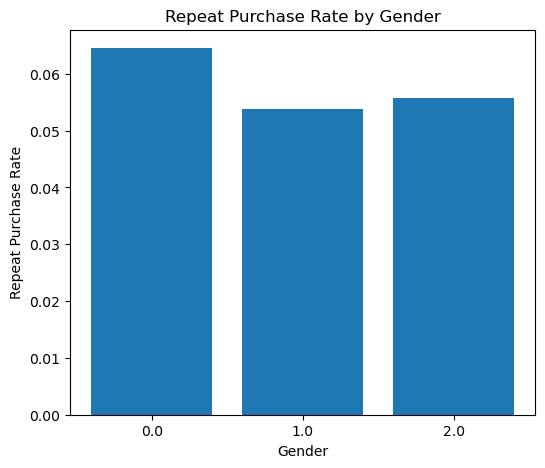


🎉 可视化分析完成！
funnel_analysis.csv 已保存！


In [7]:
# =========================================================
# 天猫用户重复购买预测 - 可视化分析模块（最终版）
# 包含：
# 1. 行为漏斗分析
# 2. 年龄分布分析
# 3. 性别分布分析
# 4. 不同年龄复购率分析
# 5. 不同性别复购率分析
# =========================================================

# =========================================================
# 1. 导入库
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 2. 数据读取
# =========================================================

path = r"C:\Users\Administrator\Desktop\工作\项目二天猫用户重复购买预测\data_format1"

print("开始读取数据...")

# 训练集
train = pd.read_csv(
    path + r"\train_format1.csv"
)

# 用户画像
user_info = pd.read_csv(
    path + r"\user_info_format1.csv"
)

# 行为日志（读取300万行）
user_log = pd.read_csv(
    path + r"\user_log_format1.csv",
    nrows=3000000
)

print("train:", train.shape)
print("user_info:", user_info.shape)
print("user_log:", user_log.shape)

# =========================================================
# 3. 缺失值处理
# =========================================================

print("开始处理缺失值...")

# 年龄缺失
user_info['age_range'] = (
    user_info['age_range']
    .fillna(0)
)

# 性别缺失
user_info['gender'] = (
    user_info['gender']
    .fillna(2)
)

# =========================================================
# 4. 用户行为漏斗分析
# =========================================================

print("\n开始行为漏斗分析...")

# 点击用户数
click_users = user_log[
    user_log['action_type'] == 0
]['user_id'].nunique()

# 加购用户数
cart_users = user_log[
    user_log['action_type'] == 1
]['user_id'].nunique()

# 购买用户数
buy_users = user_log[
    user_log['action_type'] == 2
]['user_id'].nunique()

# 收藏用户数
fav_users = user_log[
    user_log['action_type'] == 3
]['user_id'].nunique()

# 漏斗数据
funnel_labels = [
    'Click',
    'Cart',
    'Favorite',
    'Purchase'
]

funnel_values = [
    click_users,
    cart_users,
    fav_users,
    buy_users
]

# 输出结果
print("\n用户行为漏斗：")

for label, value in zip(
    funnel_labels,
    funnel_values
):

    print(label, ":", value)

# =========================================================
# 5. 绘制漏斗图
# =========================================================

plt.figure(figsize=(8,5))

plt.bar(
    funnel_labels,
    funnel_values
)

plt.title("User Behavior Funnel")

plt.xlabel("Behavior")

plt.ylabel("User Count")

plt.show()

# =========================================================
# 6. 年龄分布分析
# =========================================================

print("\n开始年龄分布分析...")

age_counts = (
    user_info['age_range']
    .value_counts()
    .sort_index()
)

print("\n年龄分布：")
print(age_counts)

# 绘图
plt.figure(figsize=(8,5))

plt.bar(
    age_counts.index.astype(str),
    age_counts.values
)

plt.title("Age Distribution")

plt.xlabel("Age Range")

plt.ylabel("User Count")

plt.show()

# =========================================================
# 7. 性别分布分析
# =========================================================

print("\n开始性别分布分析...")

gender_counts = (
    user_info['gender']
    .value_counts()
    .sort_index()
)

print("\n性别分布：")
print(gender_counts)

# 绘图
plt.figure(figsize=(6,5))

plt.bar(
    gender_counts.index.astype(str),
    gender_counts.values
)

plt.title("Gender Distribution")

plt.xlabel("Gender")

plt.ylabel("User Count")
plt.savefig("性别分布分析.png")
plt.show()

# =========================================================
# 8. 不同年龄复购率分析
# =========================================================

print("\n开始不同年龄复购率分析...")

# 合并年龄
train_age = train.merge(

    user_info[
        ['user_id', 'age_range']
    ],

    on='user_id',

    how='left'
)

# 缺失填充
train_age['age_range'] = (
    train_age['age_range']
    .fillna(0)
)

# 计算复购率
age_repeat_rate = train_age.groupby(
    'age_range'
)['label'].mean()

print("\n不同年龄复购率：")
print(age_repeat_rate)

# 绘图
plt.figure(figsize=(8,5))

plt.plot(

    age_repeat_rate.index.astype(str),

    age_repeat_rate.values,

    marker='o'
)

plt.title("Repeat Purchase Rate by Age")

plt.xlabel("Age Range")

plt.ylabel("Repeat Purchase Rate")
plt.savefig("不同年龄复购率分析.png")

plt.show()

# =========================================================
# 9. 不同性别复购率分析
# =========================================================

print("\n开始不同性别复购率分析...")

# 合并性别
train_gender = train.merge(

    user_info[
        ['user_id', 'gender']
    ],

    on='user_id',

    how='left'
)

# 缺失填充
train_gender['gender'] = (
    train_gender['gender']
    .fillna(2)
)

# 计算复购率
gender_repeat_rate = train_gender.groupby(
    'gender'
)['label'].mean()

print("\n不同性别复购率：")
print(gender_repeat_rate)

# 绘图
plt.figure(figsize=(6,5))

plt.bar(

    gender_repeat_rate.index.astype(str),

    gender_repeat_rate.values
)

plt.title("Repeat Purchase Rate by Gender")

plt.xlabel("Gender")

plt.ylabel("Repeat Purchase Rate")
plt.savefig("不同性别复购率分析.png")
plt.show()

# =========================================================
# 10. 保存漏斗分析结果
# =========================================================

funnel_df = pd.DataFrame({

    'Behavior': funnel_labels,

    'User_Count': funnel_values
})

funnel_df.to_csv(

    "funnel_analysis.csv",

    index=False
)

print("\n🎉 可视化分析完成！")
print("funnel_analysis.csv 已保存！")
